# Visualización de Series Temporales con Matplotlib

**Curso:** Python para Ciencia de Datos  \
**Fecha:** 20 de octubre de 2025  \
**Ruta:** Fundamentos de Data Science e IA \
**Repositorio:** `bootcamp-fundamentos-ciencia-de-datos`

## 📋 Índice

1. [¿Qué son las Series Temporales?](#concepto)
2. [Herramientas Necesarias](#herramientas)
3. [Sintaxis Básica](#sintaxis)
4. [Ejemplos Básicos](#ejemplos)
5. [Casos de Uso en Data Science](#casos-uso)
6. [Recursos Adicionales](#recursos)

## ¿Qué son las Series Temporales?

Las **series temporales** son secuencias de datos ordenados cronológicamente que permiten analizar:

- **Tendencias:** Patrones de crecimiento o decrecimiento a largo plazo
- **Estacionalidad:** Patrones que se repiten en periodos regulares
- **Ciclos:** Variaciones que no tienen periodo fijo
- **Anomalías:** Valores atípicos o comportamientos inusuales

Los **gráficos de líneas** son la herramienta visual principal para series temporales.

## Herramientas Necesarias

Para trabajar con series temporales necesitamos:

| Librería | Propósito |
|----------|-----------|
| **NumPy** | Operaciones numéricas y generación de datos |
| **Pandas** | Manejo de fechas y DataFrames temporales |
| **Matplotlib** | Creación de gráficos |
| **matplotlib.dates** | Formato personalizado de fechas |

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# Configuración para visualización
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## Sintaxis Básica

### Generación de Fechas con Pandas

Para crear rangos de fechas usamos `pd.date_range()`:

In [26]:
# Crear rango de fechas diarias
fechas_diarias = pd.date_range(start='2025-01-01', periods=30, freq='D')
print("Fechas diarias:")
print(fechas_diarias[:5])  # Primeras 5 fechas

# Crear rango de fechas mensuales
fechas_mensuales = pd.date_range(start='2025-01-01', periods=12, freq='ME')
print("\nFechas mensuales:")
print(fechas_mensuales[:5])

Fechas diarias:
DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05'],
              dtype='datetime64[ns]', freq='D')

Fechas mensuales:
DatetimeIndex(['2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31'],
              dtype='datetime64[ns]', freq='ME')


### Parámetros de `pd.date_range()`

- `start`: Fecha inicial
- `periods`: Número de puntos
- `freq`: Frecuencia
  - `'D'`: Diario
  - `'W'`: Semanal
  - `'ME'`: Final de mes (Month End)
  - `'h'`: Horario

## Ejemplos Básicos

### Ejemplo 1: Serie Temporal Simple

In [27]:
# Generar datos de ejemplo
dates = pd.date_range(start='2025-01-01', periods=100)
values = np.random.rand(100).cumsum()

# Crear DataFrame
data = pd.DataFrame({'Date': dates, 'Value': values})

# Mostrar primeras filas
print(data.head())

        Date     Value
0 2025-01-01  0.642878
1 2025-01-02  0.955537
2 2025-01-03  1.523351
3 2025-01-04  1.812471
4 2025-01-05  1.896396


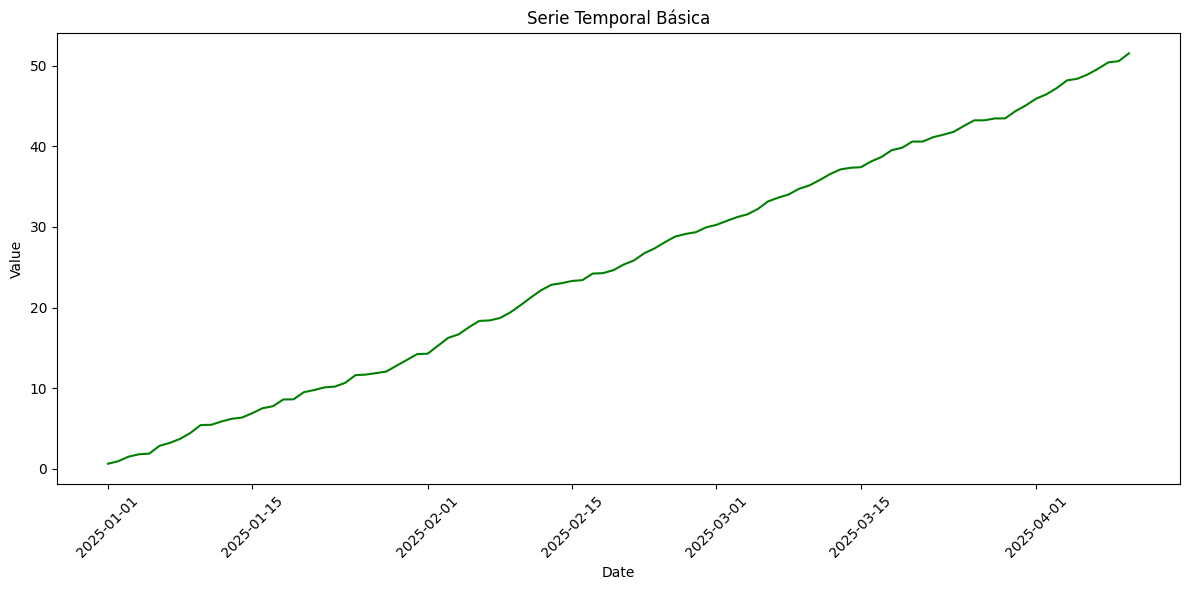

In [28]:
# Crear gráfico básico
plt.plot(data['Date'], data['Value'], color='green')
plt.xticks(rotation=45)
plt.title('Serie Temporal Básica')
plt.xlabel('Date')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

### Ejemplo 2: Serie Temporal con Formato Personalizado de Fechas

In [29]:
# Generar datos mensuales
dates = pd.date_range(start='2025-01-01', periods=12, freq='ME')
sales = np.random.randint(1000, 5000, size=12)

# Crear DataFrame
sales_data = pd.DataFrame({'Date': dates, 'Sales': sales})

print(sales_data)

         Date  Sales
0  2025-01-31   3632
1  2025-02-28   1422
2  2025-03-31   4335
3  2025-04-30   2215
4  2025-05-31   3875
5  2025-06-30   3227
6  2025-07-31   3616
7  2025-08-31   1015
8  2025-09-30   4478
9  2025-10-31   1831
10 2025-11-30   4827
11 2025-12-31   2500


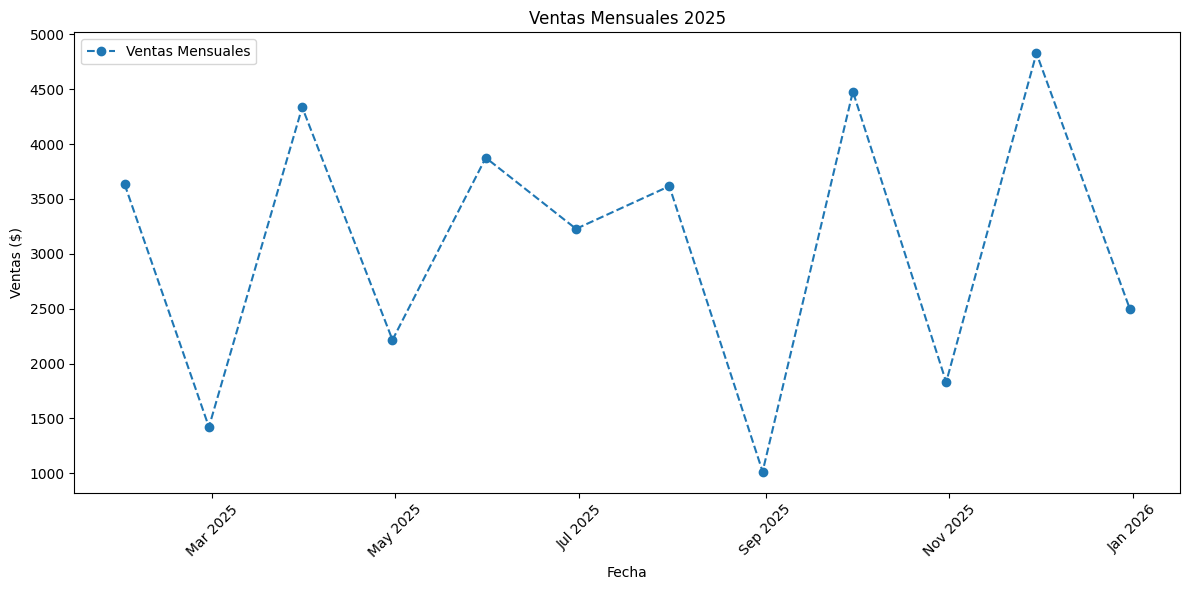

In [30]:
# Graficar con formato personalizado
plt.plot(sales_data['Date'], sales_data['Sales'],
         marker='o', linestyle='--', label='Ventas Mensuales')

# Aplicar formato de fecha
plt.gca().xaxis.set_major_formatter(DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.title('Ventas Mensuales 2025')
plt.xlabel('Fecha')
plt.ylabel('Ventas ($)')
plt.legend()
plt.tight_layout()
plt.show()

### Códigos de Formato de Fechas Comunes

| Código | Significado | Ejemplo |
|--------|-------------|---------|
| `%Y` | Año completo | 2025 |
| `%m` | Mes numérico | 01 |
| `%b` | Mes abreviado | Jan |
| `%B` | Mes completo | January |
| `%d` | Día del mes | 15 |
| `%H` | Hora (24h) | 14 |

## Casos de Uso en Data Science

### Caso de Uso 1: Análisis de Ventas de E-commerce

**Contexto:** Una tienda online necesita analizar sus ventas diarias durante 90 días para identificar patrones de compra y planificar inventario.

**Objetivo:** Detectar tendencias y patrones semanales en las ventas.

In [31]:
# Simular datos de ventas con tendencia y estacionalidad
np.random.seed(42)
dates = pd.date_range(start='2025-01-01', periods=90, freq='D')

# Crear tendencia creciente + patrón semanal + ruido
trend = np.linspace(1000, 1500, 90)
weekly_pattern = 200 * np.sin(np.arange(90) * 2 * np.pi / 7)
noise = np.random.normal(0, 100, 90)
sales = trend + weekly_pattern + noise

# Crear DataFrame
data = pd.DataFrame({'Fecha': dates, 'Ventas': sales})

print(data.head(10))

       Fecha       Ventas
0 2025-01-01  1049.671415
1 2025-01-02  1148.157844
2 2025-01-03  1270.990391
3 2025-01-04  1255.933666
4 2025-01-05   912.279825
5 2025-01-06   809.690610
6 2025-01-07  1035.262850
7 2025-01-08  1116.069316
8 2025-01-09  1154.362678
9 2025-01-10  1299.803385


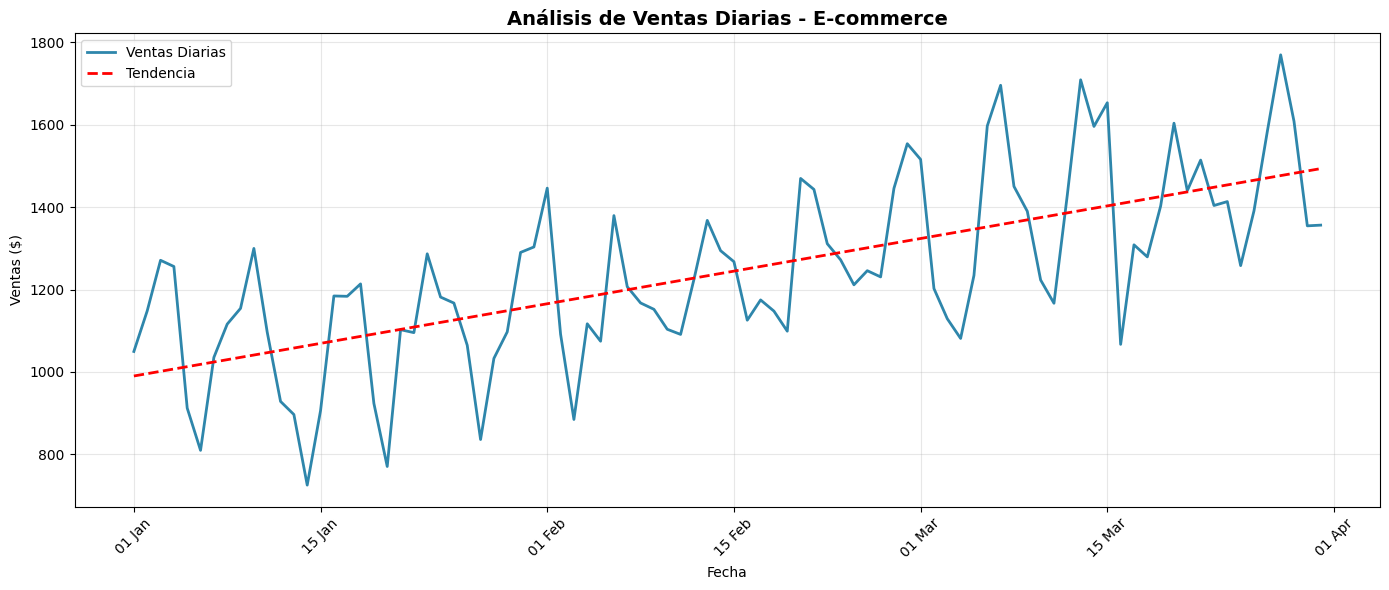

In [32]:
# Visualizar ventas con línea de tendencia
plt.figure(figsize=(14, 6))

# Gráfico principal
plt.plot(data['Fecha'], data['Ventas'],
         color='#2E86AB', linewidth=2, label='Ventas Diarias')

# Añadir línea de tendencia
z = np.polyfit(range(90), sales, 1)
p = np.poly1d(z)
plt.plot(data['Fecha'], p(range(90)),
         color='red', linestyle='--', linewidth=2, label='Tendencia')

plt.gca().xaxis.set_major_formatter(DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.title('Análisis de Ventas Diarias - E-commerce', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Ventas ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insights del Caso 1:**

- Se observa una **tendencia creciente** en las ventas
- Existe un **patrón semanal** (posiblemente mayores ventas los fines de semana)
- Esta información permite:
  - Planificar stock para días de alta demanda
  - Programar campañas de marketing estratégicamente
  - Prever necesidades de personal

### Caso de Uso 2: Monitoreo de Temperatura para Control de Calidad

**Contexto:** Una empresa farmacéutica necesita monitorear la temperatura de refrigeradores cada hora durante 7 días. Los medicamentos deben mantenerse entre 2°C y 8°C.

**Objetivo:** Detectar anomalías que pongan en riesgo el producto.

In [35]:
# Simular datos de temperatura con algunas anomalías
np.random.seed(94)
dates = pd.date_range(start='2025-01-01', periods=168, freq='h')  # 7 días

# Temperatura normal con variación + anomalías
temp_normal = np.random.normal(5, 1, 168)  # Media 5°C, desv 1°C
temp_normal[50:55] = np.random.uniform(9, 11, 5)   # Anomalía 1: Sobrecalentamiento
temp_normal[120:125] = np.random.uniform(0, 1, 5)  # Anomalía 2: Subfriamiento

data = pd.DataFrame({'Fecha_Hora': dates, 'Temperatura': temp_normal})

print(data.head(10))

           Fecha_Hora  Temperatura
0 2025-01-01 00:00:00     5.743453
1 2025-01-01 01:00:00     6.521183
2 2025-01-01 02:00:00     4.293143
3 2025-01-01 03:00:00     6.752778
4 2025-01-01 04:00:00     2.816579
5 2025-01-01 05:00:00     4.000277
6 2025-01-01 06:00:00     3.990388
7 2025-01-01 07:00:00     5.031044
8 2025-01-01 08:00:00     4.994978
9 2025-01-01 09:00:00     5.459166


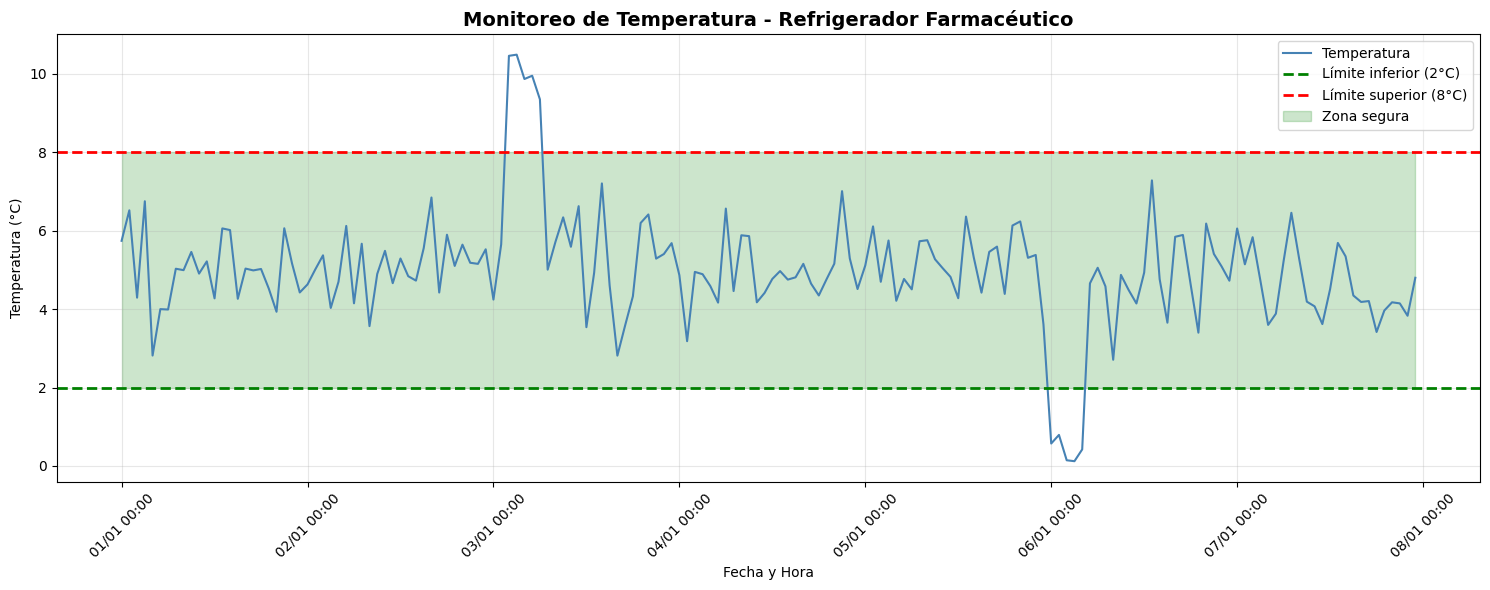

In [36]:
# Visualización con límites de seguridad
plt.figure(figsize=(15, 6))

# Línea de temperatura
plt.plot(data['Fecha_Hora'], data['Temperatura'],
         color='steelblue', linewidth=1.5, label='Temperatura')

# Líneas de referencia (límites seguros)
plt.axhline(y=2, color='green', linestyle='--', linewidth=2, label='Límite inferior (2°C)')
plt.axhline(y=8, color='red', linestyle='--', linewidth=2, label='Límite superior (8°C)')

# Zona segura sombreada
plt.fill_between(data['Fecha_Hora'], 2, 8, alpha=0.2, color='green', label='Zona segura')

plt.gca().xaxis.set_major_formatter(DateFormatter('%d/%m %H:00'))
plt.xticks(rotation=45)
plt.title('Monitoreo de Temperatura - Refrigerador Farmacéutico', fontsize=14, fontweight='bold')
plt.xlabel('Fecha y Hora')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# Análisis de alertas
alertas = data[(data['Temperatura'] < 2) | (data['Temperatura'] > 8)]
print(f"⚠️ Total de mediciones fuera del rango seguro: {len(alertas)}")
print(f"📊 Porcentaje de tiempo en riesgo: {(len(alertas)/len(data)*100):.2f}%")
print("\nPrimeras alertas detectadas:")
print(alertas.head())

⚠️ Total de mediciones fuera del rango seguro: 10
📊 Porcentaje de tiempo en riesgo: 5.95%

Primeras alertas detectadas:
            Fecha_Hora  Temperatura
50 2025-01-03 02:00:00    10.462933
51 2025-01-03 03:00:00    10.492716
52 2025-01-03 04:00:00     9.871527
53 2025-01-03 05:00:00     9.954796
54 2025-01-03 06:00:00     9.351748


**Insights del Caso 2:**

- Se detectaron **{len(alertas)} mediciones** fuera del rango seguro
- Permite identificar:
  - Patrones que indican fallas en el equipo
  - Momentos exactos de las anomalías
  - Cumplimiento de regulaciones
- Acción inmediata ante desviaciones críticas

## Recursos Adicionales

### Documentación Oficial
- [Matplotlib Date Formatting](https://matplotlib.org/stable/api/dates_api.html)
- [Pandas Time Series](https://pandas.pydata.org/docs/user_guide/timeseries.html)

### Archivos Relacionados
- `23_mpl_series_temporales.ipynb` - Este notebook
- Próximo tema: Subplots y gráficos múltiples

### Conexión con el Proyecto Final
Las series temporales serán fundamentales para analizar la evolución de la satisfacción del cliente (CSAT) a lo largo del tiempo en el proyecto "Customer Experience Analyzer".